In [10]:
import sys
sys.path.append('../')
from train_ga_mdm import *
from functools import partial

# normalize the lie algebra and check the normalization of a batch
from torch.utils.data import DataLoader
    # Optional Anomaly Detection (enable via env)
    # if os.getenv("TORCH_ANOMALY_DETECT", "0") == "1":
    #     torch.autograd.set_detect_anomaly(True)
num_steps = 60000
batch_size = 16
# data_path = "joints"
data_path = "test_data"
dataset = NPZDictDataset(data_path, keys=set(DIFFUSE_KEYS + ANSWER_KEYS))
# ---for repeat sampling during debugging---
steps_per_epoch = 10
sampler = RandomSampler(dataset, replacement=True,
            num_samples=batch_size * steps_per_epoch)
batch_sampler = BatchSampler(sampler, batch_size=batch_size, drop_last=True)
# ---for repeat sampling during debugging---

loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=8, collate_fn=dict_array_collate_fn, pin_memory=True)
num_epochs = num_steps // batch_size
save_interval = 5000 // batch_size
model = ga_mdm()
opt = AdamW(
    # with amp, we don't need to use the mp_trainer's master_params
    model.parameters(),
    lr=1e-3,
    weight_decay=0.0,
    betas=(0.9, 0.999),
)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode='min',
    factor=0.9,
    patience=5,
    min_lr=1e-6,
)
schedule_sampler = UniformSampler(TOTAL_DIFFUSION_STEPS)
step = 0
fail_count = 0
LOG_EVERY_N = int(os.getenv("LOG_EVERY_N", "50"))
logger.info(f"Train steps: {num_steps}")
gen = iter(loader)
batch = next(gen)

Loading BERT...


100%|██████████| 267967963/267967963 [00:32<00:00, 8152939.70B/s] 
2025-12-04 03:19:15,791 | INFO | train_utils | Train steps: 60000


In [2]:
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.shape} {v.dtype} {v.device}")

body_rotors: torch.Size([4, 182, 21, 16]) torch.float32 cpu
acceleration_root_motor: torch.Size([8, 180, 1, 16]) torch.float32 cpu
velocity_root_motor: torch.Size([8, 181, 1, 16]) torch.float32 cpu
log_acceleration_root_translator: torch.Size([3, 180, 1, 16]) torch.float32 cpu
chained_body_rotors: torch.Size([8, 182, 21, 16]) torch.float32 cpu
log_body_rotors_0: torch.Size([3, 182, 21, 16]) torch.float32 cpu
log_velocity_body_rotors_0: torch.Size([3, 181, 21, 16]) torch.float32 cpu
log_velocity_root_rotor_0: torch.Size([3, 181, 1, 16]) torch.float32 cpu
velocity_body_rotors: torch.Size([4, 181, 21, 16]) torch.float32 cpu
acceleration_body_rotors: torch.Size([4, 180, 21, 16]) torch.float32 cpu
log_acceleration_root_rotor: torch.Size([3, 180, 1, 16]) torch.float32 cpu
root_motor: torch.Size([8, 182, 1, 16]) torch.float32 cpu
log_acceleration_body_rotors: torch.Size([3, 180, 21, 16]) torch.float32 cpu
log_velocity_root_translator_0: torch.Size([3, 181, 1, 16]) torch.float32 cpu


In [10]:
batch['lengths']

{'body_rotors': [40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  24,
  40,
  40,
  40,
  40],
 'velocity_body_rotors': [39,
  39,
  39,
  39,
  39,
  39,
  39,
  39,
  39,
  39,
  39,
  23,
  39,
  39,
  39,
  39],
 'acceleration_root_motor': [38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  22,
  38,
  38,
  38,
  38],
 'velocity_root_motor': [39,
  39,
  39,
  39,
  39,
  39,
  39,
  39,
  39,
  39,
  39,
  23,
  39,
  39,
  39,
  39],
 'acceleration_body_rotors': [38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  22,
  38,
  38,
  38,
  38],
 'log_acceleration_root_translator': [38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  38,
  22,
  38,
  38,
  38,
  38],
 'root_motor': [40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  24,
  40,
  40,
  40,
  40],
 'chained_body_rotors': [40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  40,
  24,
  40,
  40,
  40,
  40],
 'log_acceleration_body_rotors': [

In [ ]:
from ga_mdm import *
batch = next(gen)
self = model
t, weights = schedule_sampler.sample(batch['batch_size'])
noise_level = t

with torch.no_grad():
    answers = {k: batch[k] for k in ANSWER_KEYS}
    caption = batch.pop('text_caption')
    lengths = batch.pop('lengths')
    bs = batch['batch_size']
    # Just a key of full lengths
    lengths = lengths[FULL_LENGTH_KEY]
    diffuse_shapes = [(batch[k].shape[0], batch[k].shape[2]) for k in DIFFUSE_KEYS]
    batch = diffuse_lie_data(batch, noise_level, DIFFUSE_KEYS, self.alphas_cum)
#     diffused = batch.copy()
#     # batch = accumulations(batch)
#     keys = list(batch.keys())
#     new_keys = []
#     for k in keys:
#         if not isinstance(batch[k], MultiVector):
#             continue
#         stats_key = k.replace('_0', '').replace('_1', '')
#         if stats_key not in STATS_MAP:
#             continue
#         batch[k] = kingdon_flatten(batch[k])                      # [blades, nodes, T, B]
#         batch[k] = flat_normalize(batch[k], stats_key)
#         new_keys.append(k)

# # Precompute node graph PE in latent space and pool across nodes to a global graph token
# # GRAPH_PE: [nodes, 6] -> graph_pe_latent_nodes: [nodes, latent]
# batch['id_lie_tensor'] = torch.zeros_like(batch['log_velocity_root_translator_0'])
# new_keys.append('id_lie_tensor')
# graph_pe_latent = self.node_pe(GRAPH_PE)  # [total_nodes, latent_dim]
# for k in new_keys:
#     batch[k] = self._project_mv(k, batch[k], graph_pe_latent)  # [nodes*T, B, latent]

# batch = dictionary_flatten(batch)
# batch = torch.nan_to_num(batch, nan=0.0, posinf=10.0, neginf=-10.0)
# batch = torch.clamp(batch, -10., 10.)
# log_tensor_stats("input/after_flatten", batch, level=logging.DEBUG)

# # Prepare text conditioning
# enc_text, text_mask = bert_encode_text(caption, device=device)
# if text_mask.shape[0] == 1 and bs > 1:  # casting mask for the single-prompt-for-all case
#     text_mask = torch.repeat_interleave(text_mask, bs, dim=0)

# level_emb = self.embed_timestep(noise_level.to(device))
# text_emb = self.embed_text(self.mask_cond(enc_text, force_mask=False))  # casting mask for the single-prompt-for-all case
# emb = text_emb + level_emb

# # batch = torch.cat((emb, batch), axis=0)
# batch = self.sequence_pos_encoder(batch)

# seq_len = batch.shape[0]
# mask = create_mask(lengths).to(device)
# assert mask.shape[1] == seq_len, f"Mask S={mask.shape[1]} != input S={seq_len}"
# # Warn if any sequence is fully masked (degenerate attention)
# fully_masked = mask.all(dim=1)
# if bool(fully_masked.any()):
#     bad_idx = torch.nonzero(fully_masked).flatten().tolist()
#     logger.warning(f"Fully-masked rows in src_key_padding_mask at indices {bad_idx}; seq_len={seq_len}, lengths[bad]={[lengths[i] for i in bad_idx]}")
# # batch = self.seqTransEncoder(batch, src_key_padding_mask=mask)[1:]

In [14]:
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.shape}")

body_rotors: torch.Size([4, 40, 21, 16])
velocity_body_rotors: torch.Size([4, 39, 21, 16])
log_velocity_root_translator_0: torch.Size([3, 1, 1, 16])
acceleration_root_motor: torch.Size([8, 38, 1, 16])
velocity_root_motor: torch.Size([8, 39, 1, 16])
acceleration_body_rotors: torch.Size([4, 38, 21, 16])
floor_0: torch.Size([4, 1, 1, 16])
log_velocity_root_rotor_0: torch.Size([3, 1, 1, 16])
log_velocity_body_rotors_0: torch.Size([3, 1, 21, 16])
log_acceleration_root_translator: torch.Size([3, 38, 1, 16])
root_motor: torch.Size([8, 40, 1, 16])
chained_body_rotors: torch.Size([8, 40, 21, 16])
log_body_rotors_0: torch.Size([3, 1, 21, 16])
log_acceleration_body_rotors: torch.Size([3, 38, 21, 16])
log_acceleration_root_rotor: torch.Size([3, 38, 1, 16])


In [30]:
def diffuse_lie_data(torch_data, noise_level, diffuse_keys, alpha_cum, pred_len=1):
    r = alpha_cum[noise_level]
    diffused_data = {}
    prefix_data = {}
    for k in diffuse_keys:
        # temperary fix for _0 keys
        if k.endswith('_0'):
            prefix_data[k] = alg.multivector(keys=KEY_MAP[k.replace('_0', '')], values=torch_data[k][:, :1, ...].to(device))
            continue
        dist = gaussian_from_stats(**STATS_MAP[k])
        sample = dist.sample((pred_len, torch_data[k].shape[-1])).permute(2, 0, 3, 1).to(torch_data[k].device)
        blended = ((1 - r) * torch_data[k][:, -pred_len:, ...] + r * sample).to(device)
        diffused_data[k] = alg.multivector(keys=KEY_MAP[k.replace('_0', '')], values=blended)
        prefix_data[k] = alg.multivector(keys=KEY_MAP[k.replace('_0', '')], values=torch_data[k][:, :-pred_len, ...].to(device))
    return prefix_data, diffused_data

torch_data = deepcopy(batch)
prefix_data, diffused_data = diffuse_lie_data(torch_data, noise_level, DIFFUSE_KEYS, self.alphas_cum)

In [31]:
for k,v in prefix_data.items():
    print(f"prefix_data {k}: {v.shape} {v.values()[0].device}")
for k,v in diffused_data.items():
    print(f"diffused_data {k}: {v.shape} {v.values()[0].device}")

prefix_data log_acceleration_root_translator: torch.Size([3, 37, 1, 16]) cuda:0
prefix_data log_acceleration_root_rotor: torch.Size([3, 37, 1, 16]) cuda:0
prefix_data log_velocity_root_translator_0: torch.Size([3, 1, 1, 16]) cuda:0
prefix_data log_velocity_root_rotor_0: torch.Size([3, 1, 1, 16]) cuda:0
prefix_data log_acceleration_body_rotors: torch.Size([3, 37, 21, 16]) cuda:0
prefix_data log_velocity_body_rotors_0: torch.Size([3, 1, 21, 16]) cuda:0
prefix_data log_body_rotors_0: torch.Size([3, 1, 21, 16]) cuda:0
prefix_data floor_0: torch.Size([4, 1, 1, 16]) cuda:0
diffused_data log_acceleration_root_translator: torch.Size([3, 1, 1, 16]) cuda:0
diffused_data log_acceleration_root_rotor: torch.Size([3, 1, 1, 16]) cuda:0
diffused_data log_acceleration_body_rotors: torch.Size([3, 1, 21, 16]) cuda:0


In [32]:
prefix_data = accumulations(prefix_data)
for k,v in prefix_data.items():
    print(f"prefix_data {k}: {v.shape}")

prefix_data log_acceleration_root_translator: torch.Size([3, 37, 1, 16])
prefix_data log_acceleration_root_rotor: torch.Size([3, 37, 1, 16])
prefix_data log_velocity_root_translator_0: torch.Size([3, 1, 1, 16])
prefix_data log_velocity_root_rotor_0: torch.Size([3, 1, 1, 16])
prefix_data log_acceleration_body_rotors: torch.Size([3, 37, 21, 16])
prefix_data log_velocity_body_rotors_0: torch.Size([3, 1, 21, 16])
prefix_data log_body_rotors_0: torch.Size([3, 1, 21, 16])
prefix_data floor_0: torch.Size([4, 1, 1, 16])
prefix_data acceleration_root_translator: (4, 37, 1, 16)
prefix_data acceleration_root_rotor: (4, 37, 1, 16)
prefix_data velocity_root_translator_0: (4, 1, 1, 16)
prefix_data velocity_root_rotor_0: (4, 1, 1, 16)
prefix_data acceleration_body_rotors: (4, 37, 21, 16)
prefix_data velocity_body_rotors_0: (4, 1, 21, 16)
prefix_data body_rotors_0: (4, 1, 21, 16)
prefix_data root_motor_1: (8, 1, 1, 16)
prefix_data root_motor: torch.Size([8, 37, 1, 16])
prefix_data velocity_root: torch

In [6]:
def build_time_causal_mask(seq_len: int, device: torch.device) -> torch.Tensor:
    """
    Build an additive causal mask for nn.TransformerDecoder.
    Shape: [seq_len, seq_len]; 0 where allowed, -inf where disallowed.
    """
    mask = torch.full((seq_len, seq_len), float('-inf'), device=device)
    mask = torch.triu(mask, diagonal=1)  # upper triangle -inf, diagonal and below 0
    return mask

time_causal_mask = build_time_causal_mask(seq_len, device)

time_causal_mask

tensor([[0., -inf, -inf,  ..., -inf, -inf, -inf],
        [0., 0., -inf,  ..., -inf, -inf, -inf],
        [0., 0., 0.,  ..., -inf, -inf, -inf],
        ...,
        [0., 0., 0.,  ..., 0., -inf, -inf],
        [0., 0., 0.,  ..., 0., 0., -inf],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')

In [7]:
mask

tensor([[False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True]], device='cuda:0')

In [4]:
batch = next(gen)
t, weights = schedule_sampler.sample(batch['batch_size'])
batch, answers, diffuse_shapes = model(batch, t)

In [4]:
import sys
sys.path.append('../')
from train_ga_mdm import *
from tqdm import tqdm
from torch.utils.data import DataLoader, RandomSampler, BatchSampler

num_steps = 80
batch_size = 4
# data_path = "joints"
data_path = "test_data"
dataset = NPZDictDataset(data_path, keys=set(DIFFUSE_KEYS + ANSWER_KEYS))
# ---for repeat sampling during debugging---
steps_per_epoch = 10
sampler = RandomSampler(dataset, replacement=True,
            num_samples=batch_size * steps_per_epoch)
batch_sampler = BatchSampler(sampler, batch_size=batch_size, drop_last=True)
# ---for repeat sampling during debugging---

loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=8, collate_fn=dict_array_collate_fn, pin_memory=True)
num_epochs = num_steps // (batch_size*steps_per_epoch)
save_interval = 5000 // batch_size
model = ga_mdm()
opt = AdamW(
    # with amp, we don't need to use the mp_trainer's master_params
    model.parameters(),
    lr=1e-3,
    weight_decay=0.0,
    betas=(0.9, 0.999),
)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode='min',
    factor=0.9,
    patience=5,
    min_lr=1e-6,
)
schedule_sampler = UniformSampler(TOTAL_DIFFUSION_STEPS)
step = 0
fail_count = 0
LOG_EVERY_N = int(os.getenv("LOG_EVERY_N", "50"))
logger.info(f"Train steps: {num_steps}")

# register hooks for logging gradients
# register hooks
layers_monitoring, grads_monitoring = get_all_layers(model, hook_forward, hook_backward)


for epoch in range(num_epochs):
    logger.info(f'Starting epoch {epoch}')
    total_loss = 0.0
    for batch in tqdm(loader):
        step += 1
        t, weights = schedule_sampler.sample(batch['batch_size'])
        # TESTING: fixed noise level
        # t = torch.ones(batch_size, dtype=torch.int64) * 5
        batch, answers, diffuse_shapes = model(batch, t)

        loss = compute_loss(batch, answers, diffuse_shapes, use_ema=False)
        with torch.no_grad():
            if torch.isnan(loss) or torch.isinf(loss):
                logger.warning(f"Skipping step {step} due to NaN/Inf loss")
                del batch
                opt.zero_grad()
                torch.cuda.empty_cache()
                fail_count += 1
                if fail_count > 10:
                    logger.error("Too many consecutive failures due to loss NaN/Inf. Exiting.")
                    exit(1)
                continue
        total_loss += loss.item()
        loss.backward()
        opt.step()
        if step % save_interval == 0:
            save_checkpoint(model, opt, lr_scheduler, epoch+1, loss, filename=f"checkpoint_step_{step}.pt")
    avg_train_loss = total_loss / len(loader)
    logger.info(f"Epoch {epoch+1}, train_loss={avg_train_loss:.6f}")
    lr_scheduler.step(avg_train_loss)

2025-12-01 11:48:55,486 | INFO | train_utils | Train steps: 80
2025-12-01 11:48:55,489 | INFO | train_utils | Starting epoch 0
  0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.8/dist-packages/torch/nn/functional.py:5109: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
100%|██████████| 10/10 [00:04<00:00,  2.41it/s]
2025-12-01 11:48:59,647 | INFO | train_utils | Epoch 1, train_loss=32869648.400000
2025-12-01 11:48:59,648 | INFO | train_utils | Starting epoch 1
100%|██████████| 10/10 [00:04<00:00,  2.43it/s]
2025-12-01 11:49:03,769 | INFO | train_utils | Epoch 2, train_loss=35059012.600000


In [6]:
def get_grads(grads):
    layer_idx = []
    avg_grads = []
    for idx, (name, grad) in enumerate(grads):
        if grad is not None:
            avg_grad = grad.abs().mean().to('cpu').item()
            avg_grads.append(avg_grad)
            # idx is backwards since we appended in backward pass
            layer_idx.append(len(grads) - 1 - idx)
    return layer_idx, avg_grads

layer_idx_bn, avg_grads_bn = get_grads(grads_monitoring)

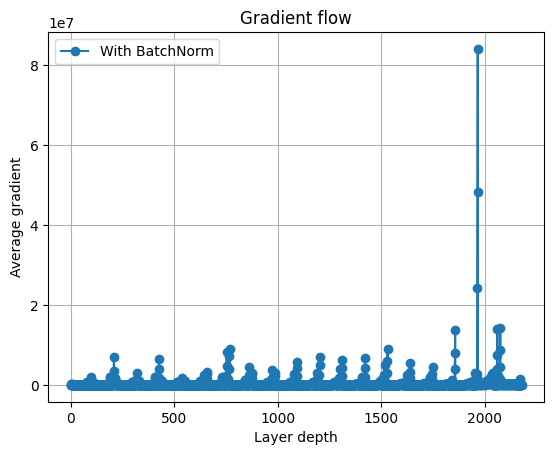

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(layer_idx_bn, avg_grads_bn, label="With BatchNorm", marker="o")
ax.set_xlabel("Layer depth")
ax.set_ylabel("Average gradient")
ax.set_title("Gradient flow")
ax.grid(True)
ax.legend()
plt.show()

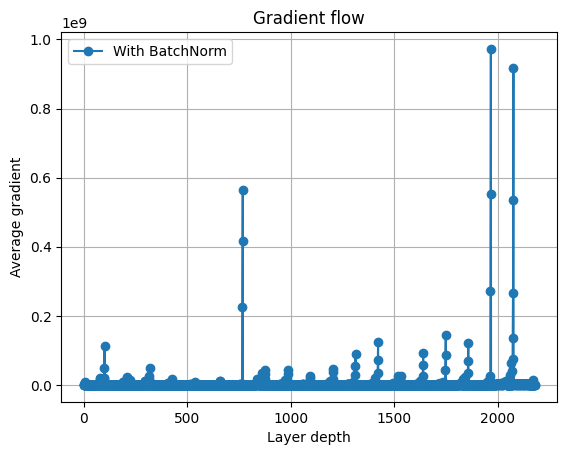

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(layer_idx_bn, avg_grads_bn, label="With BatchNorm", marker="o")
ax.set_xlabel("Layer depth")
ax.set_ylabel("Average gradient")
ax.set_title("Gradient flow")
ax.grid(True)
ax.legend()
plt.show()

In [15]:
v = motor_split_log(batch['body_rotors'])
k = 'log_body_rotors'
v_flat = kingdon_flatten(v)
v_norm = flat_normalize(v_flat, k)
print(f"{k}: mean {v_norm.mean().item():.6f}, std {v_norm.std().item():.6f}")
print(f"{k}: mean {v_flat.mean().item():.6f}, std {v_flat.std().item():.6f}")

log_body_rotors: mean 0.094111, std 9.818488
log_body_rotors: mean 0.004135, std 0.689064


In [3]:
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape)

log_velocity_root_translator_0 torch.Size([3, 1, 1, 4])
log_body_rotors_0 torch.Size([3, 1, 21, 4])
acceleration_body_rotors torch.Size([4, 38, 21, 4])
floor_0 torch.Size([4, 1, 1, 4])
root_motor torch.Size([8, 40, 1, 4])
log_acceleration_root_translator torch.Size([3, 38, 1, 4])
log_acceleration_root_rotor torch.Size([3, 38, 1, 4])
acceleration_root_motor torch.Size([8, 38, 1, 4])
velocity_root_motor torch.Size([8, 39, 1, 4])
log_acceleration_body_rotors torch.Size([3, 38, 21, 4])
body_rotors torch.Size([4, 40, 21, 4])
log_velocity_body_rotors_0 torch.Size([3, 1, 21, 4])
chained_body_rotors torch.Size([8, 40, 21, 4])
velocity_body_rotors torch.Size([4, 39, 21, 4])
log_velocity_root_rotor_0 torch.Size([3, 1, 1, 4])


In [1]:
import torch
torch.cuda.empty_cache()

In [ ]:
kinematic_child_parent

NameError: name 'kinematic_child_parent' is not defined